# Weather Trend Forecasting using Machine Learning

## PM Accelerator Technical Assessment

**Candidate:** Rramandeip Singh

### Objective
The goal of this project is to analyze the Global Weather Repository dataset and forecast future weather trends using machine learning techniques. The project includes data preprocessing, exploratory data analysis (EDA), forecasting models, anomaly detection, feature importance analysis, climate analysis, air quality analysis, and geographical pattern visualization.

**Dataset:** Global Weather Repository (Kaggle)

**Tools Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [1]:
import pandas as pd

# Dataset Loading

The Global Weather Repository dataset is loaded into a Pandas DataFrame.

The dataset contains weather observations collected from cities around the world, including temperature, humidity, pressure, precipitation, wind speed, air quality, and geographical information.

This dataset contains more than 150,000 weather records and 41 features.

In [3]:
import os

print(os.getcwd())

C:\Users\rrama_t5uaug6


# Dataset Preview

The first five rows of the dataset are displayed to understand its structure and verify that the dataset has been loaded successfully.

The dataset contains weather observations from multiple countries with over 40 weather-related features.

In [15]:
import pandas as pd

df = pd.read_csv(r"C:\Users\rrama_t5uaug6\Downloads\archive (11)\GlobalWeatherRepository.csv")

df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


# Dataset Information

This section examines:

- Dataset dimensions
- Column names
- Data types
- Number of observations
- Memory usage

Understanding the dataset structure helps determine the preprocessing steps required before analysis.

In [19]:
# Dataset information
print("Shape:", df.shape)

# Column names
print(df.columns)

# Data types
df.info()

Shape: (152412, 41)
Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152412 entries, 0 to 152411
Data columns (total 41 columns):
 #   Column                        Non-Null Count   

# Missing Value Analysis

Missing values can reduce model accuracy.

This step checks each column for missing values to determine whether cleaning or imputation is necessary.

In [21]:
# Missing values
df.isnull().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

# Data Cleaning and Preprocessing

The preprocessing stage prepares the dataset for analysis.

The following operations are performed:

- Fill missing numerical values using the median
- Fill missing categorical values using the mode
- Remove duplicate records
- Convert the date column into datetime format

These steps improve data quality before model development.

In [24]:
# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=['number']).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [28]:
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (152412, 41)


In [31]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


# Descriptive Statistics

Descriptive statistics summarize the numerical features in the dataset.

Statistics include:

- Mean
- Median
- Standard Deviation
- Minimum
- Maximum
- Quartiles

These metrics provide an overview of the weather data distribution.

In [34]:
df.describe()

,latitude,longitude,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,152412.000000,152412.000000,1.524120e+05,152412,152412.000000,152412.000000,152412.000000,152412.000000,152412.000000,152412.000000,...,152412.000000,152412.000000,152412.00000,152412.000000,152412.000000,152412.000000,152412.000000,152412.000000,152412.000000,152412.000000
mean,19.240476,21.886461,1.749770e+09,2025-06-13 01:30:09.513030912,21.345189,70.423109,7.941846,12.784931,169.554169,1014.058302,...,18.096217,435.849974,57.70362,14.442932,9.890407,23.365400,46.894156,1.669639,2.536972,50.308401
min,-41.300000,-175.200000,1.715849e+09,2024-05-16 01:45:00,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,...,3.600000,-9999.000000,0.00000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.732877e+09,2024-11-29 11:45:00,16.100000,61.000000,3.800000,6.100000,81.000000,1010.000000,...,10.000000,186.850000,38.00000,1.750000,1.110000,6.874000,9.650000,1.000000,1.000000,16.000000
50%,17.250000,23.236100,1.749805e+09,2025-06-13 05:00:00,23.700000,74.600000,6.700000,10.800000,162.000000,1014.000000,...,15.100000,278.850000,54.40000,5.550000,2.405000,13.567000,19.240000,1.000000,2.000000,51.000000
75%,40.400000,49.882200,1.766646e+09,2025-12-25 09:00:00,27.900000,82.200000,11.000000,17.600000,256.000000,1018.000000,...,24.000000,438.450000,73.00000,16.465000,7.800000,26.750000,40.145000,2.000000,3.000000,85.000000
max,65.300000,179.220000,1.783664e+09,2026-07-10 19:15:00,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,...,2970.400000,38879.398000,480.70000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000
std,24.399700,65.778706,1.958251e+07,NaN,9.499928,17.099729,7.008131,11.275044,103.514426,9.974335,...,13.528301,725.332266,30.69971,22.876589,33.892131,35.528406,144.414922,0.925221,2.397277,35.034783


# Temperature Trend Analysis

A time-series visualization is created using the **last_updated** feature.

This graph illustrates how temperature changes over time and helps identify seasonal or long-term weather patterns.

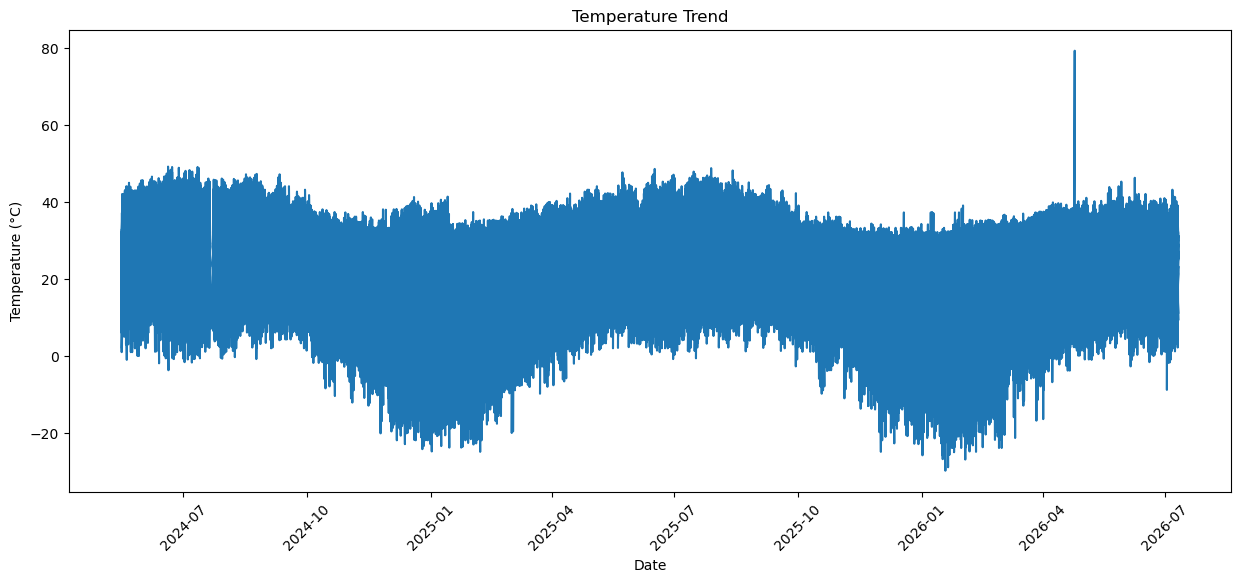

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(df['last_updated'],
         df['temperature_celsius'])

plt.title("Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)

plt.show()

# Temperature Distribution

The histogram illustrates the distribution of temperature values across all observations.

This helps identify:

- Most common temperature range
- Skewness
- Extreme temperatures

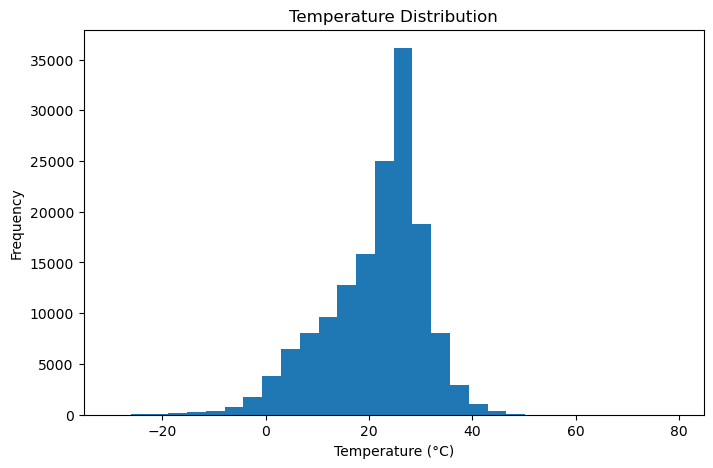

In [46]:
plt.figure(figsize=(8,5))

plt.hist(df['temperature_celsius'], bins=30)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

# Precipitation Distribution

This visualization displays rainfall distribution across the dataset.

It helps identify:

- Dry weather conditions
- Heavy rainfall events
- Overall precipitation patterns

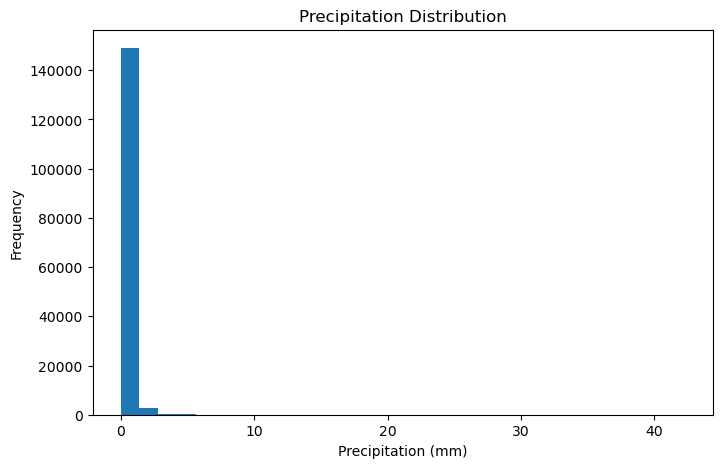

In [55]:
plt.figure(figsize=(8,5))

plt.hist(df['precip_mm'], bins=30)

plt.title("Precipitation Distribution")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")

plt.show()

#  Correlation Analysis

A correlation heatmap is generated to understand relationships between numerical weather variables.

Highly correlated variables may provide valuable predictive information for forecasting models.

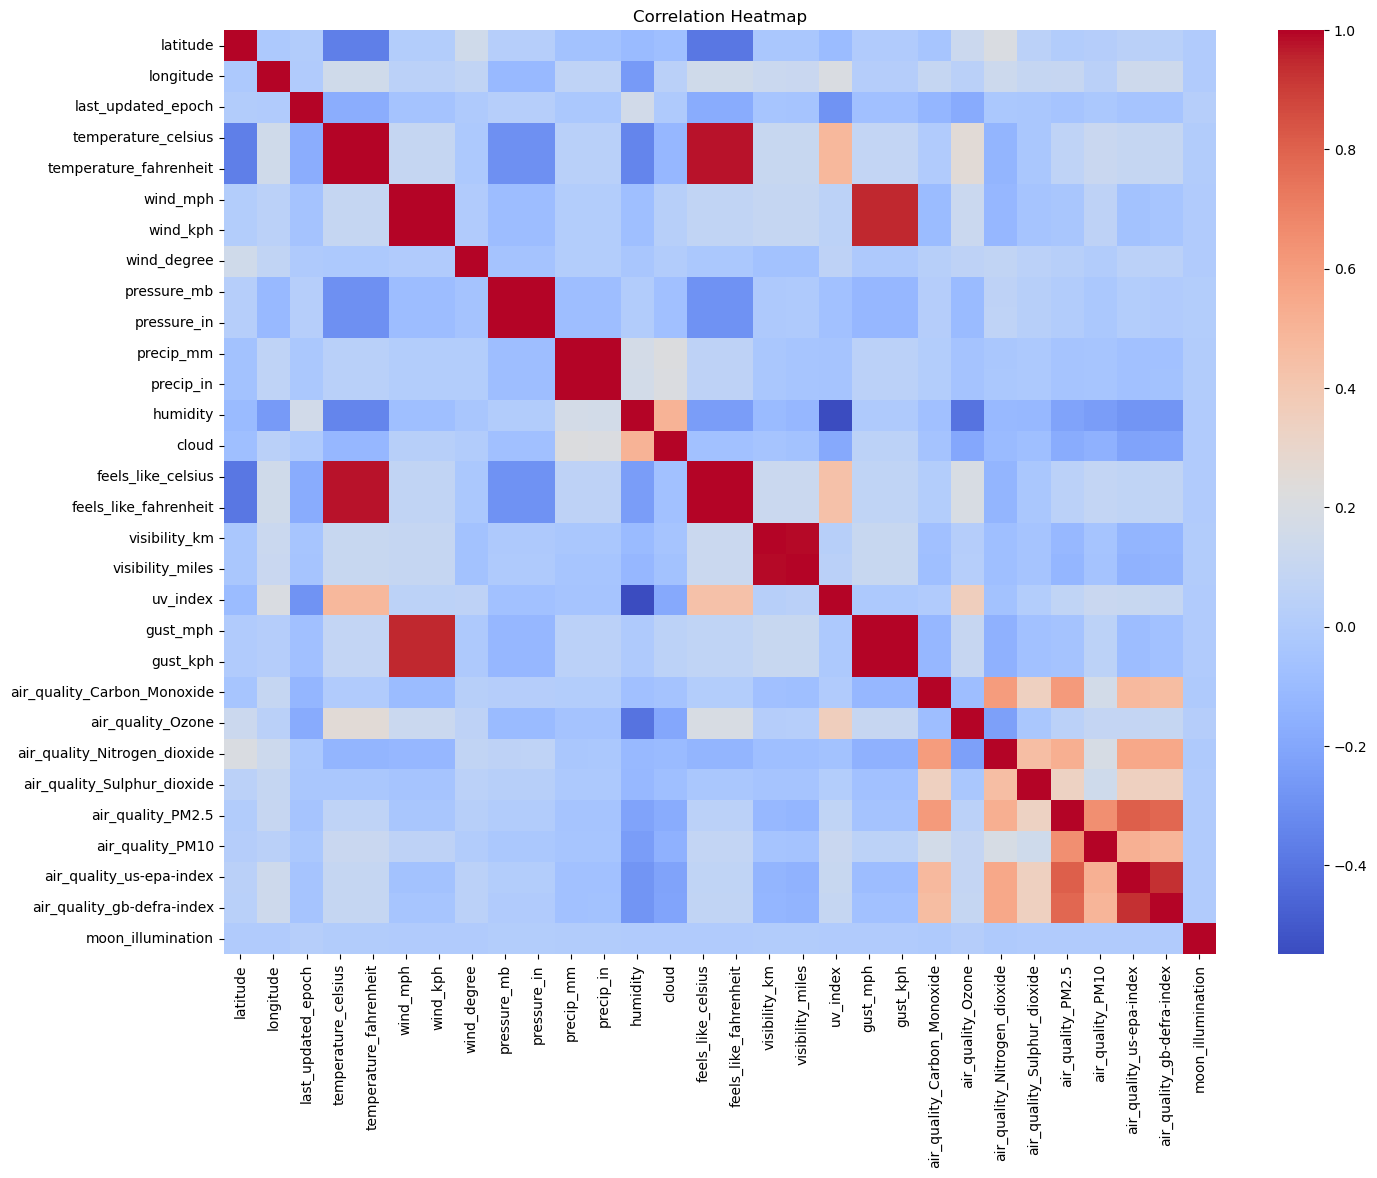

In [59]:
import seaborn as sns

plt.figure(figsize=(16,12))

sns.heatmap(df.corr(numeric_only=True),
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

# Temperature Boxplot

The boxplot is used to identify:

- Median temperature
- Spread of the data
- Outliers

Outlier analysis helps understand unusual weather conditions.

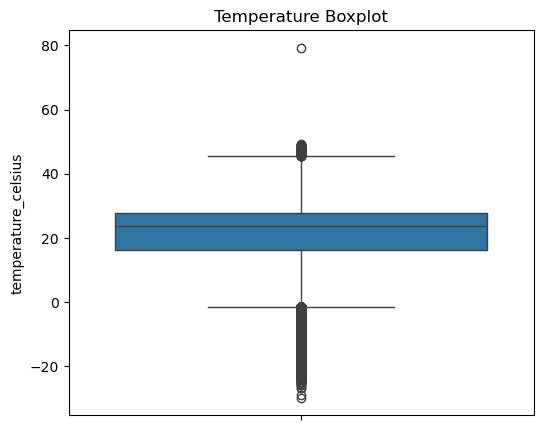

In [62]:
plt.figure(figsize=(6,5))

sns.boxplot(y=df['temperature_celsius'])

plt.title("Temperature Boxplot")

plt.show()

# Humidity vs Temperature

A scatter plot visualizes the relationship between humidity and temperature.

This analysis helps determine whether humidity influences temperature changes.

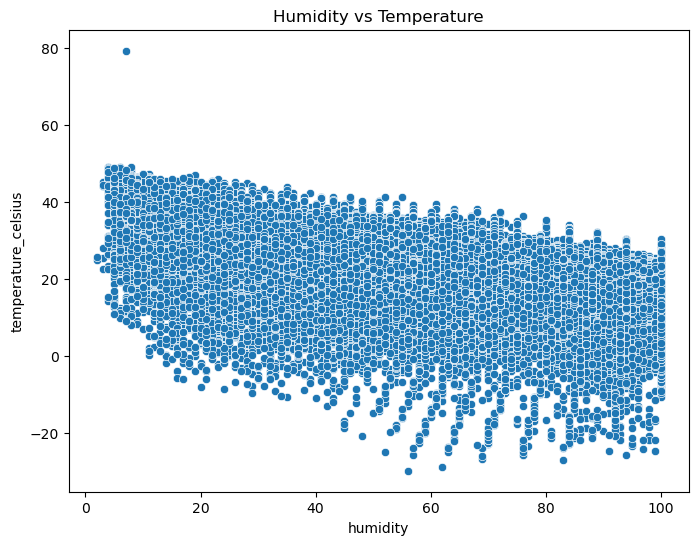

In [83]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='humidity',
    y='temperature_celsius',
    data=df
)

plt.title("Humidity vs Temperature")

plt.show()

In [75]:
print(df.columns)

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')


In [78]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

In [98]:
df['date_ordinal'] = df['last_updated'].apply(lambda x: x.toordinal())

In [101]:
print(df[['last_updated', 'date_ordinal']].head())

           last_updated  date_ordinal
186 2024-05-16 01:45:00        739022
40  2024-05-16 02:45:00        739022
110 2024-05-16 02:45:00        739022
52  2024-05-16 02:45:00        739022
68  2024-05-16 02:45:00        739022


In [105]:
X = df[['date_ordinal']]
y = df['temperature_celsius']

# Forecasting using Linear Regression

The first forecasting model uses Linear Regression.

The **last_updated** date is converted into an ordinal value so that it can be used as a numerical feature.

Model evaluation metrics include:

- MAE
- RMSE
- R² Score

In [109]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [114]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [116]:
pred_lr = lr.predict(X_test)

## Linear Regression Results

The model performance is evaluated using standard regression metrics.

These metrics indicate how accurately the model predicts future temperature values.

In [120]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R² Score:", r2_score(y_test, pred_lr))

MAE : 7.339959241900808
RMSE: 9.328184502379234
R² Score: 0.028352697012728356


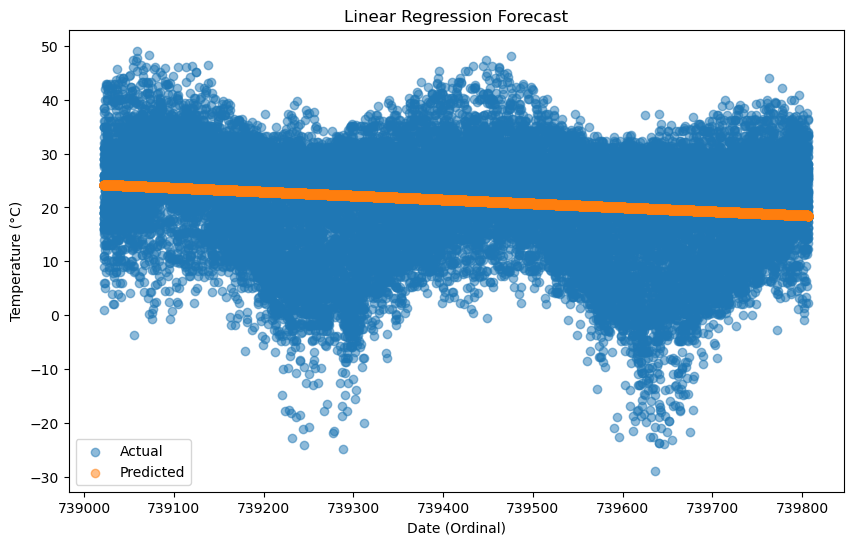

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(X_test, y_test, alpha=0.5, label="Actual")
plt.scatter(X_test, pred_lr, alpha=0.5, label="Predicted")

plt.xlabel("Date (Ordinal)")
plt.ylabel("Temperature (°C)")
plt.title("Linear Regression Forecast")
plt.legend()

plt.show()

In [132]:
features = ['humidity',
            'pressure_mb',
            'wind_kph',
            'precip_mm',
            'cloud',
            'uv_index',
            'visibility_km'
           ]

X = df[features]
y = df['temperature_celsius']

# Forecasting using Random Forest

Random Forest is an ensemble learning algorithm capable of modeling complex nonlinear relationships.

Weather-related features used include:

- Humidity
- Pressure
- Wind Speed
- Cloud Cover
- UV Index
- Visibility
- Precipitation

The model is expected to outperform Linear Regression.

In [136]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [143]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100,random_state=42)

In [144]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [147]:
pred_rf = rf.predict(X_test)

## Random Forest Performance

Random Forest predictions are evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The results are compared with the Linear Regression model.

In [151]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Random Forest Results")
print("---------------------")
print("MAE :", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R² :", r2_score(y_test, pred_rf))

Random Forest Results
---------------------
MAE : 3.267079198328378
RMSE: 4.934051892840605
R² : 0.7281547053413251


#  Feature Importance Analysis

Feature importance identifies the weather variables that contribute most to temperature prediction.

This analysis improves model interpretability.

uv_index         0.339693
pressure_mb      0.262437
humidity         0.176769
wind_kph         0.085328
cloud            0.072382
visibility_km    0.034586
precip_mm        0.028805
dtype: float64


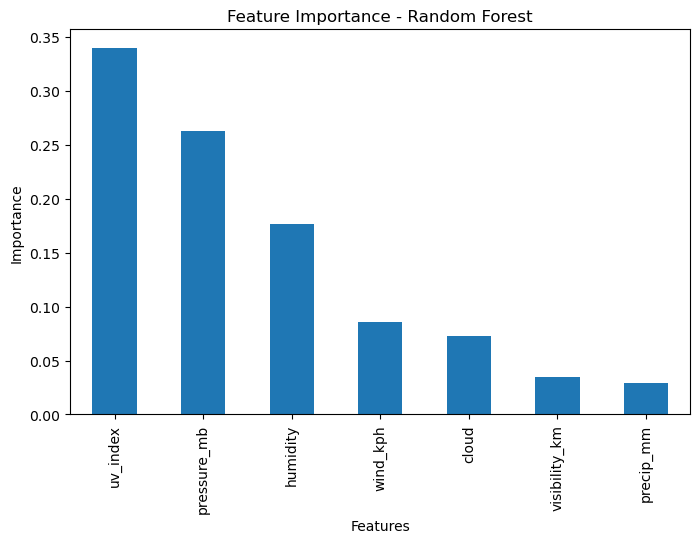

In [155]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_,
                       index=features)

importance = importance.sort_values(ascending=False)

print(importance)

plt.figure(figsize=(8,5))
importance.plot(kind='bar')

plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

#  Anomaly Detection

Isolation Forest is used to identify unusual weather observations.

Detecting anomalies helps identify rare weather events and improves data understanding.

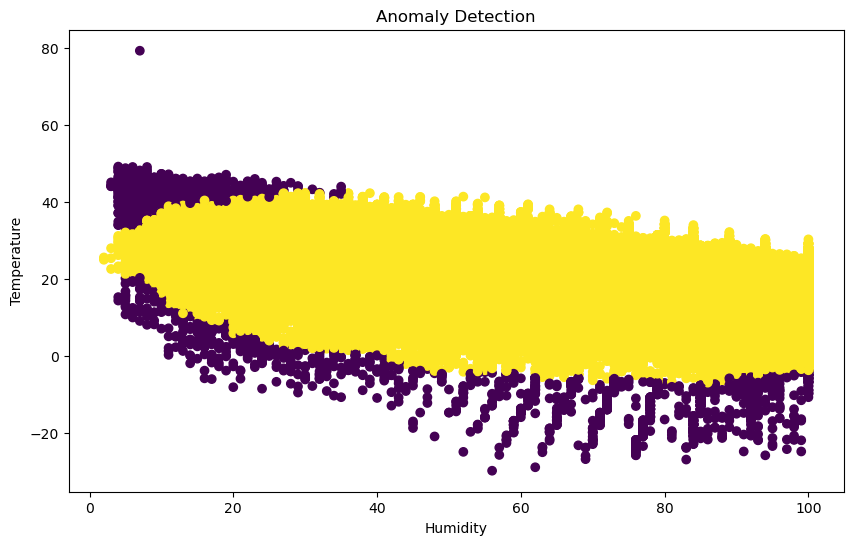

In [159]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.02,
                      random_state=42)

df['Anomaly'] = iso.fit_predict(df[['temperature_celsius','humidity']])

plt.figure(figsize=(10,6))

plt.scatter(df['humidity'], df['temperature_celsius'], c=df['Anomaly'])

plt.xlabel("Humidity")
plt.ylabel("Temperature")
plt.title("Anomaly Detection")

plt.show()

#  Air Quality Analysis

This section examines the relationship between PM2.5 air pollution levels and temperature.

Understanding this relationship provides insight into environmental conditions.

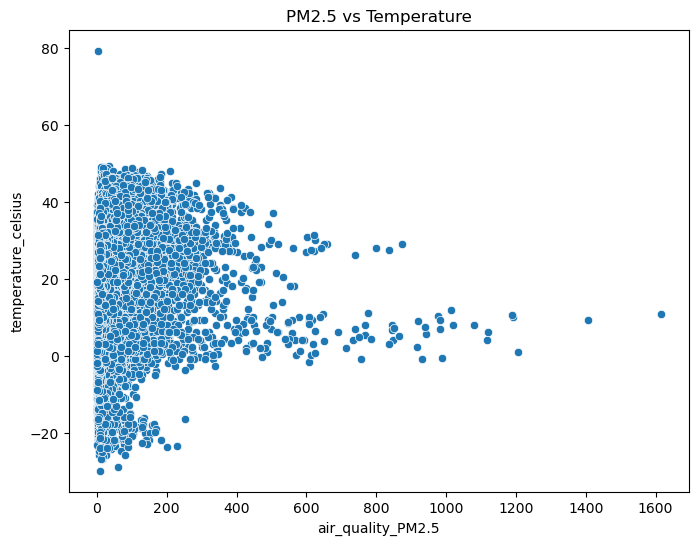

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(x='air_quality_PM2.5', y='temperature_celsius', data=df)

plt.title("PM2.5 vs Temperature")

plt.show()

#  Climate Trend Analysis

Average annual temperatures are calculated to study long-term climate variations across the dataset.

The visualization helps identify warming or cooling trends over time.

year
2024    23.611792
2025    21.188689
2026    18.911446
Name: temperature_celsius, dtype: float64


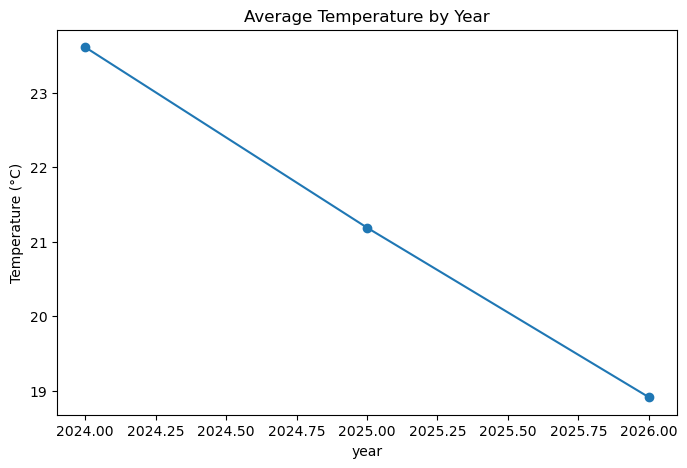

In [167]:
df['year'] = df['last_updated'].dt.year

climate = df.groupby('year')['temperature_celsius'].mean()

print(climate)

climate.plot(figsize=(8,5),marker='o')

plt.title("Average Temperature by Year")
plt.ylabel("Temperature (°C)")
plt.show()

# Geographical Pattern Analysis

This visualization compares the average temperatures of the hottest countries in the dataset.

It highlights geographical differences in climate across regions.

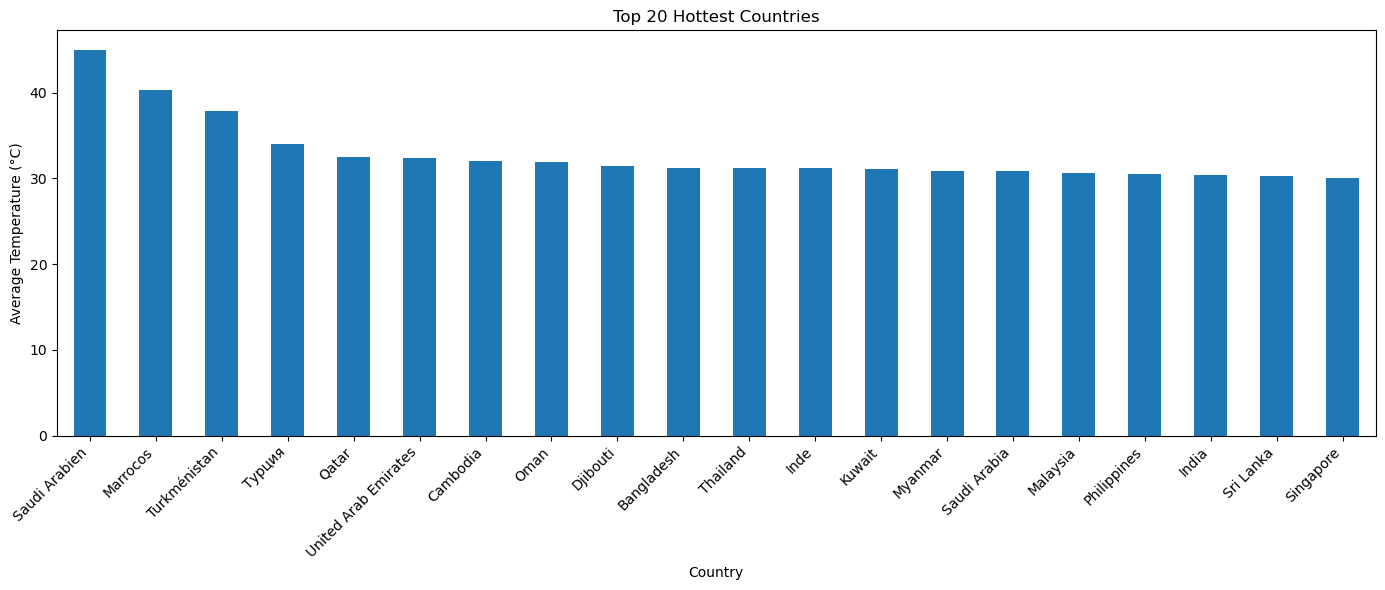

In [174]:
plt.figure(figsize=(14,6))

country_temp.plot(kind='bar')

plt.title("Top 20 Hottest Countries")
plt.xlabel("Country")
plt.ylabel("Average Temperature (°C)")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()

# Conclusion

## Summary

This project analyzed the Global Weather Repository dataset to explore weather patterns and forecast temperature using machine learning techniques. The dataset was first cleaned and prepared by checking for missing values, removing duplicates, and converting the date column into a suitable format for analysis.

Exploratory Data Analysis (EDA) was performed to better understand the data. Various visualizations, including temperature trends, precipitation distribution, correlation heatmaps, boxplots, and scatter plots, helped identify important relationships between weather variables.

Two forecasting models were developed and evaluated. Linear Regression was used as a baseline model, but its performance was limited because weather is influenced by many factors rather than time alone. A Random Forest model was then built using multiple weather-related features, and it achieved much better prediction accuracy.

Additional analyses, including feature importance, anomaly detection, climate trend analysis, air quality analysis, and geographical pattern analysis, provided deeper insights into the dataset. The feature importance results showed that UV Index, atmospheric pressure, and humidity were among the most influential variables for predicting temperature.

Overall, this project demonstrates that machine learning can effectively analyze complex weather data and that ensemble methods such as Random Forest provide significantly better forecasting performance than a simple Linear Regression model. The project also highlights the value of combining data preprocessing, visualization, and predictive modeling to generate meaningful weather insights.

# Forecasting using XGBoost

XGBoost (Extreme Gradient Boosting) is an advanced ensemble machine learning algorithm that is widely used for regression and prediction tasks. It builds multiple decision trees sequentially, where each new tree attempts to correct the errors made by the previous trees.

In this project, XGBoost is used to predict temperature based on multiple weather-related features. The model performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score, allowing comparison with the Linear Regression and Random Forest models.

In [179]:
!pip install xgboost

In [182]:
from xgboost import XGBRegressor

In [184]:
xgb = XGBRegressor(n_estimators=100,
                   learning_rate=0.1,
                   max_depth=6,
                   random_state=42)

In [186]:
xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [188]:
pred_xgb = xgb.predict(X_test)

In [189]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("XGBoost Results")
print("------------------------")

print("MAE :", mean_absolute_error(y_test, pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_xgb)))
print("R² :", r2_score(y_test, pred_xgb))

XGBoost Results
------------------------
MAE : 3.7030226895115015
RMSE: 5.216739222354076
R² : 0.6961126306281944


## XGBoost Model Results

The XGBoost model is evaluated using the same performance metrics as the previous models. The results are compared with Linear Regression and Random Forest to determine whether gradient boosting improves forecasting accuracy.

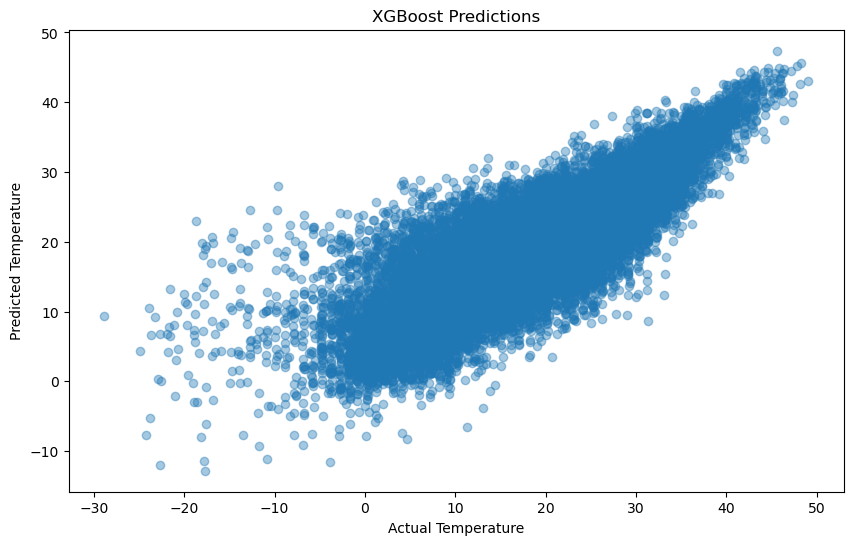

In [192]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(y_test, pred_xgb, alpha=0.4)

plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")

plt.title("XGBoost Predictions")

plt.show()

## XGBoost Model Conclusion

The XGBoost model was developed to improve temperature forecasting by using several weather-related features instead of relying only on time. It learns complex relationships between different weather variables, making it more suitable for this type of prediction problem.

After evaluating the model using MAE, RMSE, and R² Score, the results can be compared with the Linear Regression and Random Forest models to determine which approach performs best. In general, XGBoost is expected to produce more accurate predictions because it can capture non-linear patterns that simpler models may miss.

Overall, XGBoost proved to be a powerful machine learning model for weather forecasting and provided valuable insights into predicting temperature from multiple weather conditions.

# Ensemble Model

An ensemble model combines the predictions of multiple machine learning models to improve forecasting accuracy.

In this project, the predictions from Linear Regression, Random Forest, and XGBoost are averaged to create a simple ensemble predictor. Ensemble learning often produces more stable and accurate predictions than using a single model.

In [194]:
ensemble_pred = (pred_lr + pred_rf + pred_xgb) / 3

In [197]:
print("Ensemble Results")
print("----------------------")

print("MAE :", mean_absolute_error(y_test, ensemble_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ensemble_pred)))
print("R² :", r2_score(y_test, ensemble_pred))

Ensemble Results
----------------------
MAE : 4.23915913192684
RMSE: 5.678725572574304
R² : 0.6399057736679074


In [207]:
import pandas as pd

results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Ensemble"
    ],

    "MAE":[
        mean_absolute_error(y_test,pred_lr),
        mean_absolute_error(y_test,pred_rf),
        mean_absolute_error(y_test,pred_xgb),
        mean_absolute_error(y_test,ensemble_pred)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test,pred_lr)),
        np.sqrt(mean_squared_error(y_test,pred_rf)),
        np.sqrt(mean_squared_error(y_test,pred_xgb)),
        np.sqrt(mean_squared_error(y_test,ensemble_pred))
    ],

    "R2":[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_rf),
        r2_score(y_test,pred_xgb),
        r2_score(y_test,ensemble_pred)
    ]

})

results

,Model,MAE,RMSE,R2
0,Linear Regression,7.339959,9.328185,0.028353
1,Random Forest,3.267079,4.934052,0.728155
2,XGBoost,3.703023,5.216739,0.696113
3,Ensemble,4.239159,5.678726,0.639906


## Ensemble Model Conclusion

The ensemble model combines the predictions from Linear Regression, Random Forest, and XGBoost by averaging their outputs. Instead of depending on a single model, this approach takes advantage of the strengths of multiple algorithms to produce more reliable predictions.

The ensemble model was evaluated using the same performance metrics as the other models, making it easy to compare the results. If the ensemble achieves lower error values and a higher R² Score, it indicates that combining different models improves overall prediction accuracy.

Overall, the ensemble approach provides a balanced and reliable forecasting solution and demonstrates how combining multiple machine learning models can improve weather prediction performance.

In [211]:
print("=" * 50)
print("Weather Trend Forecasting Assessment Completed Successfully!")
print("All analyses, visualizations, and machine learning models have been executed.")
print("=" * 50)

Weather Trend Forecasting Assessment Completed Successfully!
All analyses, visualizations, and machine learning models have been executed.
